In [45]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv('data_science_job.csv')

In [3]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [5]:
df.shape

(19158, 13)

In [7]:
null_precentage = (df.isnull().sum()/19158)*100

In [32]:
# we will only remove those columns whose missing values are less than 5 %

In [33]:
null_precentage = null_precentage[null_precentage<5 ]

In [37]:
apply_cca = null_precentage[null_precentage>0].index

In [38]:
apply_cca

Index(['city_development_index', 'enrolled_university', 'education_level',
       'experience', 'training_hours'],
      dtype='object')

In [41]:
# total columns that will be left 
len(df[apply_cca].dropna())/len(df)

0.8968577095730244

In [42]:
new_df = df[apply_cca].dropna()

In [43]:
new_df

,city_development_index,enrolled_university,education_level,experience,training_hours
0,0.920,no_enrollment,Graduate,20.0,36.0
1,0.776,no_enrollment,Graduate,15.0,47.0
2,0.624,Full time course,Graduate,5.0,83.0
4,0.767,no_enrollment,Masters,20.0,8.0
5,0.764,Part time course,Graduate,11.0,24.0
...,...,...,...,...,...
19153,0.878,no_enrollment,Graduate,14.0,42.0
19154,0.920,no_enrollment,Graduate,14.0,52.0
19155,0.920,no_enrollment,Graduate,20.0,44.0
19156,0.802,no_enrollment,High School,0.0,97.0


In [57]:
numcols = new_df.describe().columns

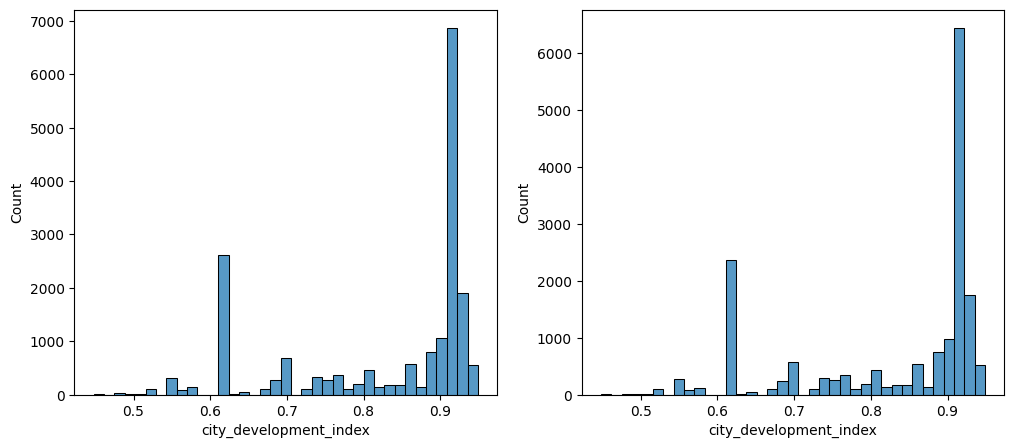

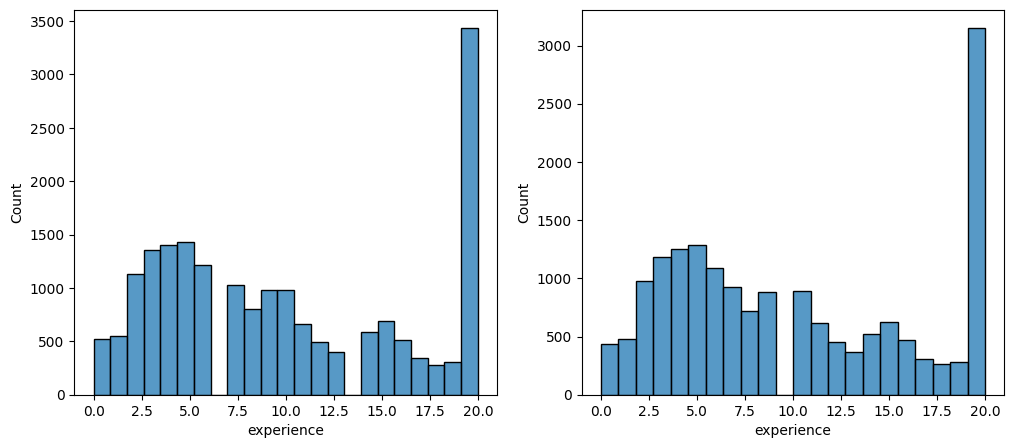

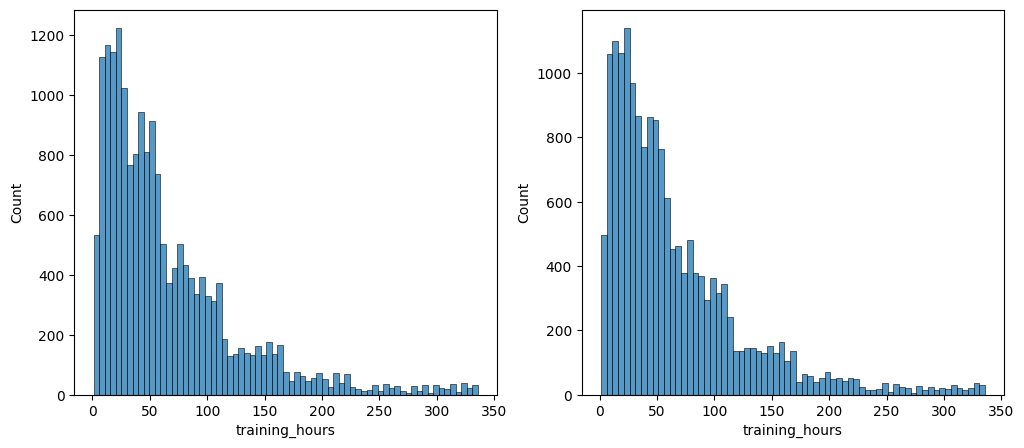

In [58]:
# now we can see the distribution graph
for i in numcols:
    plt.figure(figsize=(12,5))
    plt.subplot(121)
    sns.histplot(df[i])
    plt.subplot(122)
    sns.histplot(new_df[i])
    plt.show()

In [61]:
# we can see that the distribution of the numerical columns are still same 
# it is safe
# we can check also categorical columns by watching the ratio of the categories or the count plots of the categorical columns 
df['enrolled_university'].value_counts()/len(df)

enrolled_university
no_enrollment       0.721213
Full time course    0.196106
Part time course    0.062533
Name: count, dtype: float64

In [63]:
new_df['enrolled_university'].value_counts()/len(new_df)

enrolled_university
no_enrollment       0.735188
Full time course    0.200733
Part time course    0.064079
Name: count, dtype: float64

In [ ]:
# we must check all this before cca 